In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
import seaborn as sns
import pandas as pd

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from noshow.config import CLINIC_CONFIG
from pathlib import Path
from noshow.features.appointment_features import (
    add_appointments_last_days,
    add_appointments_same_day,
    add_days_since_created,
    add_days_since_last_appointment,
    add_minutes_early,
    add_time_features,
)
from noshow.features.no_show_features import prev_no_show_features
from noshow.features.patient_features import add_patient_features
from noshow.preprocessing.load_data import (
    load_appointment_csv,
    process_appointments,
    process_postal_codes,
)
from noshow.features.feature_pipeline import create_features
from noshow.visualisation.features_plots import feature_barplot, feature_scatter
from noshow.preprocessing.geo import haversine_distance

In [2]:
appointments_df = load_appointment_csv("../data/raw/poliafspraken_no_show.csv")
appointments_df = process_appointments(appointments_df, CLINIC_CONFIG)

/home/jovyan/No_Show/src/noshow/preprocessing/load_data.py:52: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  appointments_df = pd.read_csv(


test!!@
non unique index:
1701932


In [3]:
all_postalcodes = process_postal_codes("../data/raw/NL.csv")
appointments_features = create_features(appointments_df, all_postalcodes)

---


In [4]:
# Filter the DataFrame where the status is "Is niet voldaan"
filtered_df = appointments_df[appointments_df["status"] == 0]

#Filtering out certain clinics
filtered_df = filtered_df.loc[filtered_df["hoofdagenda"].isin(
    ["OOGHEELKUNDE"] #OOGHEELKUNDE
)]

#Filtering out locations
filtered_df = filtered_df.loc[filtered_df["ziekenhuis"].isin(
    ["HagaZiekenhuis Den Haag"] #, "HagaZiekenhuis Zoetermeer"
)]

# Get the value counts of cancelationReason_code for the filtered data, including NaN values
cancelation_reason_counts = filtered_df["cancelationReason_code"].value_counts(dropna=False)

# Display the result
print(cancelation_reason_counts)


cancelationReason_code
N      11213
NaN     5276
NF        25
Q          7
Name: count, dtype: int64


In [5]:
print(appointments_df['status'].value_counts(dropna=False))

status
1    1575212
0     126720
Name: count, dtype: int64


In [6]:
print(appointments_features['status'].value_counts(dropna=False))

status
1    1572434
0     126184
Name: count, dtype: int64


In [7]:
print(appointments_features['cancelationReason_code'].value_counts(dropna=False))

cancelationReason_code
NaN    1646032
N        50253
Q         1795
NF         538
Name: count, dtype: int64


In [8]:
#Filtering out certain clinics
appointments_features = appointments_features.loc[appointments_features["hoofdagenda"].isin(
    ["OOGHEELKUNDE"] #OOGHEELKUNDE
)]

#Filtering out locations
appointments_features = appointments_features.loc[appointments_features["ziekenhuis"].isin(
    ["HagaZiekenhuis Den Haag"] #, "HagaZiekenhuis Zoetermeer"
)]

appointments_features = appointments_features.loc[
    ~((appointments_features["status"] == "0") & 
      ~(appointments_features["cancelationReason_code"].isin(["N", "NF"])))
]

appointments_features["no_show"] = (
        appointments_features["no_show"].replace({"no_show": "1", "show": "0"}).astype(int)
    )

appointments_features["gender"] = (
        appointments_features["gender"].replace({"Man": "1", "Vrouw": "0"}).astype(int)
    )

features = ["hour",
            "weekday",
            "minutesDuration",
            "no_show", ##eruit
            "prev_no_show",
            "prev_no_show_perc",
            "age",
            "dist_umcu",
            "gender",
            "prev_minutes_early",
            "earlier_appointments",
            "appointments_same_day",
            "appointments_last_days",
            "days_since_created",
            "days_since_last_appointment"]

scaler = StandardScaler()
features_without_target = [feature for feature in features if feature != 'no_show']
X_scaled = scaler.fit_transform(appointments_features[features_without_target])

In [9]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca, columns=['PC1','PC2'])
pca_df = pca_df.set_index(appointments_features.index)

pca_df['no_show'] = appointments_features['no_show']

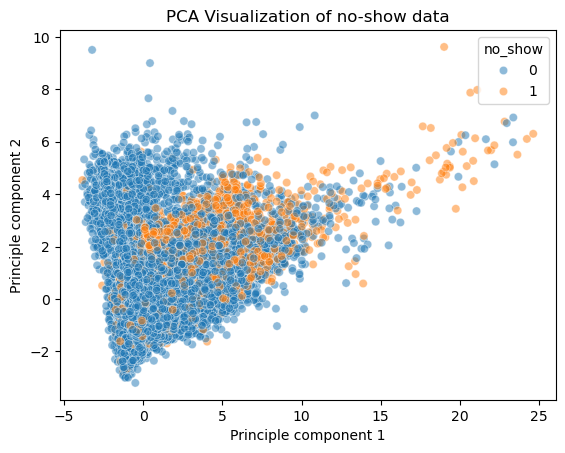

In [10]:
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], alpha=0.5 ,hue=pca_df['no_show'])
plt.xlabel('Principle component 1')
plt.ylabel('Principle component 2')
plt.title('PCA Visualization of no-show data')
plt.show()

In [11]:
pca_loadings = pd.DataFrame(pca.components_, columns=features_without_target, index=['PC1', 'PC2'])
print(pca_loadings)

         hour   weekday  minutesDuration  prev_no_show  prev_no_show_perc  \
PC1 -0.211484 -0.129230        -0.260144      0.577647           0.418117   
PC2  0.501712  0.270674         0.601679      0.187569           0.199083   

          age  dist_umcu    gender  prev_minutes_early  earlier_appointments  \
PC1 -0.000145  -0.088093  0.020565            0.056007              0.460018   
PC2 -0.343219   0.017419  0.062029            0.141228             -0.013338   

     appointments_same_day  appointments_last_days  days_since_created  \
PC1               0.222678                0.280121            0.010207   
PC2               0.221702                0.132115           -0.013244   

     days_since_last_appointment  
PC1                    -0.106333  
PC2                    -0.171266  


In [12]:
print(pca.explained_variance_ratio_)

[0.12478025 0.10644246]


In [13]:
X = appointments_features[features]

X_mean = X.mean()
X_std = X.std()
Z = (X - X_mean) / X_std

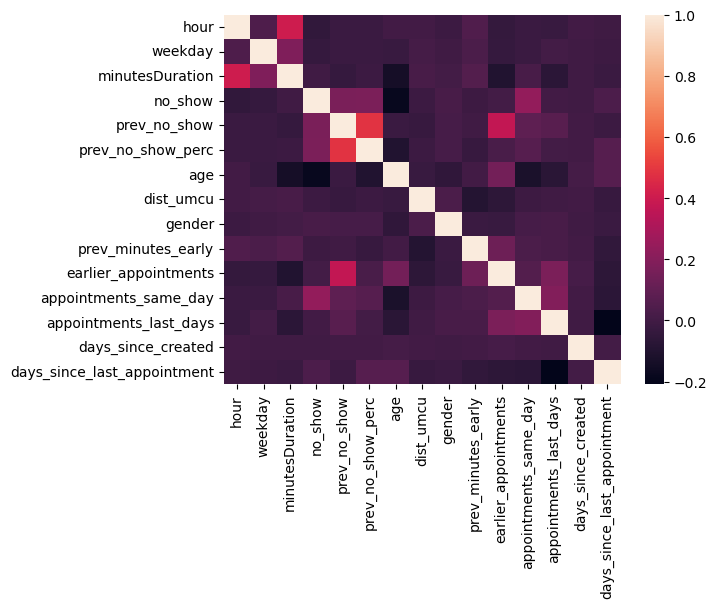

In [14]:
#linear
C = Z.cov()
sns.heatmap(C)
plt.show()

In [15]:
appointments_features['afspraak_code'].value_counts()

afspraak_code
CP         43217
CPTOA      42026
NP         32021
NPSP       22903
KL         15704
           ...  
CPS            1
VNINTRA        1
PTERYG         1
NN             1
ARG            1
Name: count, Length: 63, dtype: int64